In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.environ['KAGGLE_USERNAME'] = "nazarkg"
os.environ['KAGGLE_KEY'] = "KGAT_649715d42bc8ce67c49895276eb16e3d" # Tırnak içine anahtarı yaz
!kaggle datasets download -d hamdimohamed22/fer-2013-dataset-resized-and-augmented
!unzip -q fer-2013-dataset-resized-and-augmented.zip -d dataset

Dataset URL: https://www.kaggle.com/datasets/hamdimohamed22/fer-2013-dataset-resized-and-augmented
License(s): other
 98% 360M/369M [00:02<00:00, 97.3MB/s]
100% 369M/369M [00:02<00:00, 134MB/s] 


In [3]:
class_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

In [4]:
!pip install timm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
import os
import time
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Cihaz: {device}")

Cihaz: cuda


In [5]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dir = '/content/dataset/FER_preprocessed_train'
val_dir = '/content/dataset/preprocessed_test'
data_transforms = {
    'train': transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20), # Döndürme açısını artır
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Resmi biraz kaydır
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5), # Perspektifi değiştir
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3), # Renkleri daha fazla zorla
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'val': datasets.ImageFolder(val_dir, data_transforms['val'])
}
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True, num_workers=2),
    'val': DataLoader(image_datasets['val'], batch_size=32, shuffle=False, num_workers=2)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"Tespit edilen sınıflar: {class_names}")
print(f"Toplam Eğitim Görüntüsü: {dataset_sizes['train']}")
print(f"Toplam Test Görüntüsü: {dataset_sizes['val']}")

Tespit edilen sınıflar: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Toplam Eğitim Görüntüsü: 50415
Toplam Test Görüntüsü: 7178


In [6]:
import torch
import os
import timm

#Modeli ve Optimizer'ı tekrar tanımla
model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=7)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.05)

#Drive'daki son checkpoint'i yükle
checkpoint_path = '/content/drive/MyDrive/swin_last_checkpoint.pth'
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] # Bu değer 3 olacak
    history = checkpoint['history']
    best_acc = checkpoint['best_acc']
    print(f"Başarıyla yüklendi! {start_epoch + 1}. epochtan devam ediyoruz.")
    print(f"Şu ana kadarki en iyi başarı: %{best_acc*100:.2f}")
else:
    print("Checkpoint bulunamadı, sıfırdan başlanıyor!")
    start_epoch = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0
# EARLY STOPPING VE EĞİTİM DÖNGÜSÜ
patience = 20  # 20'ye çıkardık
trigger_times = 0
last_loss = history['val_loss'][-1] if history['val_loss'] else float('inf')
def train_resumed(model, criterion, optimizer, start_epoch, num_epochs=100):
    global best_acc, history, trigger_times, last_loss
    for epoch in range(start_epoch, num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 20)
        for phase in ['train', 'val']:
            if phase == 'train': model.train()
            else: model.eval()
            running_loss, running_corrects = 0.0, 0
            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                #EARLY STOPPING KONTROLÜ
                if epoch_loss > last_loss:
                    trigger_times += 1
                    print(f"Uyarı: Kayıp (Loss) arttı! ({trigger_times}/{patience})")
                    if trigger_times >= patience:
                        print("Early Stopping Devrede! Model daha fazla gelişmiyor.")
                        return model, history
                else:
                    trigger_times = 0
                last_loss = epoch_loss
            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: %{epoch_acc*100:.2f}')
            checkpoint = {
                'epoch': epoch + 1, #kaldığı epochtan devam etsin diye
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history,
                'best_acc': best_acc
            }
            torch.save(checkpoint, '/content/drive/MyDrive/swin_last_checkpoint.pth')
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), '/content/drive/MyDrive/swin_best_model.pth')
                print(">>> REKOR: Yeni en iyi model kaydedildi!")
    return model, history
visual_model, history = train_resumed(model, criterion, optimizer, start_epoch)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Başarıyla yüklendi! 87. epochtan devam ediyoruz.
Şu ana kadarki en iyi başarı: %70.56

Epoch 87/100
--------------------
Train Loss: 0.1469 Acc: %94.74
Val Loss: 1.4770 Acc: %70.42

Epoch 88/100
--------------------
Train Loss: 0.1482 Acc: %94.75
Uyarı: Kayıp (Loss) arttı! (1/20)
Val Loss: 1.5147 Acc: %69.88

Epoch 89/100
--------------------
Train Loss: 0.1514 Acc: %94.67
Val Loss: 1.4508 Acc: %69.62

Epoch 90/100
--------------------
Train Loss: 0.1452 Acc: %94.83
Val Loss: 1.4242 Acc: %69.21

Epoch 91/100
--------------------
Train Loss: 0.1473 Acc: %94.72
Uyarı: Kayıp (Loss) arttı! (1/20)
Val Loss: 1.4616 Acc: %70.42

Epoch 92/100
--------------------
Train Loss: 0.1422 Acc: %95.01
Uyarı: Kayıp (Loss) arttı! (2/20)
Val Loss: 1.5058 Acc: %71.11
>>> REKOR: Yeni en iyi model kaydedildi!

Epoch 93/100
--------------------
Train Loss: 0.1451 Acc: %94.79
Val Loss: 1.4798 Acc: %70.58

Epoch 94/100
--------------------
Train Loss: 0.1406 Acc: %95.00
Uyarı: Kayıp (Loss) arttı! (1/20)
Val Lo

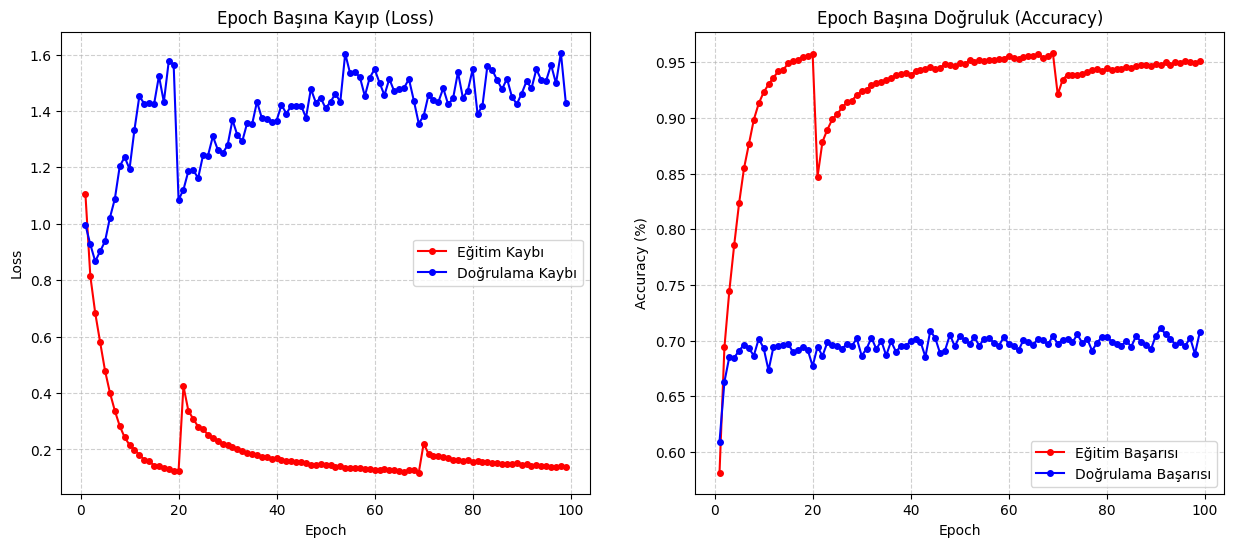

Confusion Matrix hesaplanıyor, lütfen bekleyin...


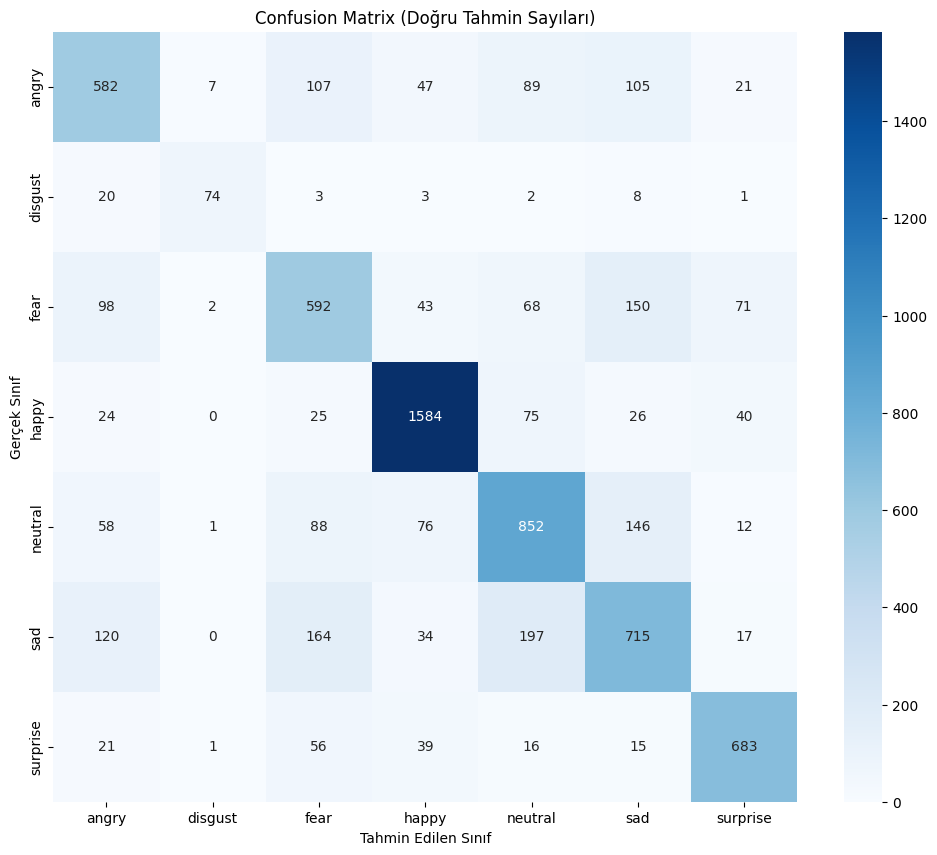


      DETAYLI SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

       angry       0.63      0.61      0.62       958
     disgust       0.87      0.67      0.76       111
        fear       0.57      0.58      0.58      1024
       happy       0.87      0.89      0.88      1774
     neutral       0.66      0.69      0.67      1233
         sad       0.61      0.57      0.59      1247
    surprise       0.81      0.82      0.82       831

    accuracy                           0.71      7178
   macro avg       0.72      0.69      0.70      7178
weighted avg       0.71      0.71      0.71      7178


Genel F1-Skoru (Weighted): %70.67

Grafikler Drive'a başarıyla kaydedildi.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import numpy as np
import torch

def plot_analysis(history, model, dataloader, class_names):
    min_len = min(len(history['train_loss']), len(history['val_loss']),
                  len(history['train_acc']), len(history['val_acc']))

    epochs = range(1, min_len + 1)
    train_loss = history['train_loss'][:min_len]
    val_loss = history['val_loss'][:min_len]
    train_acc = history['train_acc'][:min_len]
    val_acc = history['val_acc'][:min_len]

    plt.figure(figsize=(15, 6))

    # Loss Grafiği
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, 'r-o', markersize=4, label='Eğitim Kaybı')
    plt.plot(epochs, val_loss, 'b-o', markersize=4, label='Doğrulama Kaybı')
    plt.title('Epoch Başına Kayıp (Loss)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Accuracy Grafiği
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, 'r-o', markersize=4, label='Eğitim Başarısı')
    plt.plot(epochs, val_acc, 'b-o', markersize=4, label='Doğrulama Başarısı')
    plt.title('Epoch Başına Doğruluk (Accuracy)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Grafikleri kaydet
    plt.savefig('/content/drive/MyDrive/swin_egitim_grafikleri.png', dpi=300)
    plt.show()

    # Confusion Matrix (Karmaşıklık Matrisi)
    model.eval()
    all_preds = []
    all_labels = []

    print("Confusion Matrix hesaplanıyor, lütfen bekleyin...")
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    #adetli
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(12, 10))
    # fmt='d' kullanarak tam sayı (adet) gösteriyoruz
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (Doğru Tahmin Sayıları)')
    plt.ylabel('Gerçek Sınıf')
    plt.xlabel('Tahmin Edilen Sınıf')

    plt.savefig('/content/drive/MyDrive/swin_confusion_matrix_adet.png', dpi=300)
    plt.show()

    # F1-Skoru ve Detaylı Rapor
    print("\n" + "="*40)
    print("      DETAYLI SINIFLANDIRMA RAPORU")
    print("="*40)
    print(classification_report(all_labels, all_preds, target_names=class_names))

    final_f1 = f1_score(all_labels, all_preds, average='weighted')
    print(f"\nGenel F1-Skoru (Weighted): %{final_f1*100:.2f}")
    print("\nGrafikler Drive'a başarıyla kaydedildi.")

plot_analysis(history, visual_model, dataloaders['val'], class_names)

Modelin karıştırdığı görsleler

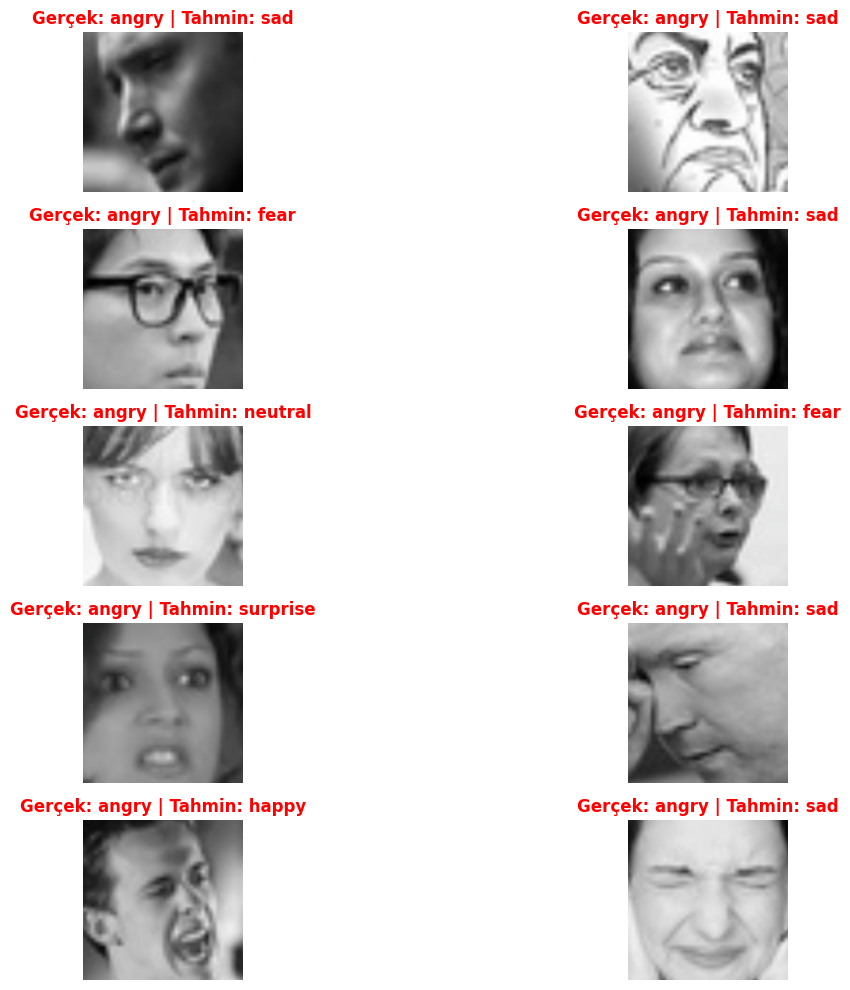

In [10]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def visualize_mistakes(model, dataloader, class_names, num_images=10):
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(15, 10))
    # model.load_state_dict(torch.load('/content/drive/MyDrive/swin_best_model.pth'))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                # Sadece YANLIŞ tahminleri yakalasın
                if preds[j] != labels[j]:
                    images_so_far += 1
                    ax = plt.subplot(num_images // 2, 2, images_so_far)
                    ax.axis('off')

                    img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                    mean = np.array([0.485, 0.456, 0.406])
                    std = np.array([0.229, 0.224, 0.225])
                    img = std * img + mean
                    img = np.clip(img, 0, 1)

                    ax.imshow(img)
                    true_label = class_names[labels[j]]
                    pred_label = class_names[preds[j]]

                    ax.set_title(f'Gerçek: {true_label} | Tahmin: {pred_label}',
                                 color='red', fontsize=12, fontweight='bold')

                    if images_so_far == num_images:
                        plt.tight_layout()
                        plt.show()
                        return

#10 tane hatalı örnek getirsin
visualize_mistakes(visual_model, dataloaders['val'], class_names, num_images=10)